Course Name: Deep Learning

Lab Title: "Leveraging Pre-trained Deep Learning Models for Remote Sensing Image Classification"

Student Name:Vaishnavi Raut

Student ID:202301100039

Date of Submission: 09-04-2026

Group Members: Sakshi Pakwanne , Kavya Mankulwar , Vaishnavi Raut , Ganesh Pardeshi

**Install & Import Libraries**

In [1]:

#  Install Libraries
!pip install -q datasets tensorflow matplotlib seaborn

import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datasets import load_dataset

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [2]:
#  Download EuroSAT + Create Small Chunk (5% balanced)
import os
import shutil
import random
from tqdm import tqdm

# 1. Download official EuroSAT RGB ZIP (95 MB only)
print("Downloading EuroSAT RGB dataset...")
!wget -q --show-progress https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip -O EuroSAT_RGB.zip

# 2. Extract the ZIP
print("\nExtracting ZIP file...")
extract_dir = "EuroSAT_full"
# Remove existing extraction directory to ensure clean state
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir) # Explicitly create the target directory

!unzip -q EuroSAT_RGB.zip -d {extract_dir}

# --- Start of Fix ---
# Verify extraction structure and set source_root dynamically
current_source_root = ""
extracted_contents = os.listdir(extract_dir)
print(f"Contents of {extract_dir} after extraction: {extracted_contents}")

# Define classes early for path detection logic
classes = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
           'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
           'River', 'SeaLake']

# Case 1: '2750' is directly inside extract_dir (e.g., EuroSAT_full/2750)
if "2750" in extracted_contents:
    current_source_root = os.path.join(extract_dir, "2750")
elif len(extracted_contents) == 1 and os.path.isdir(os.path.join(extract_dir, extracted_contents[0])):
    # Case 2: There's an intermediate directory (e.g., EuroSAT_full/EuroSAT_RGB/)
    intermediate_dir = os.path.join(extract_dir, extracted_contents[0])

    # Check if '2750' is directly inside this intermediate directory
    if os.path.exists(os.path.join(intermediate_dir, "2750")):
        current_source_root = os.path.join(intermediate_dir, "2750")
    else:
        # Fallback: Search for '2750' deeper within the intermediate directory structure
        print(f"Warning: '2750' not found directly in '{intermediate_dir}'. Searching deeper.")
        found_2750 = False
        for root, dirs, _ in os.walk(intermediate_dir):
            if "2750" in dirs:
                current_source_root = os.path.join(root, "2750")
                found_2750 = True
                break

        if not found_2750:
            # New case: What if intermediate_dir itself contains the class folders directly?
            # E.g., EuroSAT_full/EuroSAT_RGB/AnnualCrop
            # Check if any of the known classes are direct subdirectories
            if any(os.path.isdir(os.path.join(intermediate_dir, cls)) for cls in classes):
                current_source_root = intermediate_dir
                print(f"Determined source_root as intermediate directory containing class folders: {current_source_root}")
            else:
                print(f"Error: Could not find '2750' or direct class folders within '{intermediate_dir}'.")
else:
    # Case 3: '2750' is not in extract_dir and there isn't a single intermediate dir.
    # This might happen if the zip extracts directly to current directory, or a different structure.
    print(f"Error: Could not find '2750' directory within '{extract_dir}'. Checking /content for '2750'.")
    if os.path.exists("2750") and os.path.isdir("2750"):
        current_source_root = "2750"
    else:
        # Final fallback: if the original zip file contained class folders directly, and it was extracted.
        # This is less likely for EuroSAT_RGB, but keeping it generic.
        if any(os.path.isdir(os.path.join(extract_dir, cls)) for cls in classes):
            current_source_root = extract_dir
            print(f"Determined source_root as extraction directory containing class folders: {current_source_root}")
        else:
            raise FileNotFoundError(
                f"Could not locate the '2750' directory or direct class folders. "
                f"Please check the zip file contents and extraction process. "
                f"Extracted to: {extract_dir}, contents: {extracted_contents}"
            )

source_root = current_source_root
if not os.path.exists(source_root):
    raise FileNotFoundError(f"Final source_root path does not exist: {source_root}. Current value: {current_source_root}")

print(f"Determined source_root: {source_root}")
# --- End of Fix ---

# 3. Create small balanced subset (135 images per class)
print("\nCreating small balanced chunk (1,350 images)...")

small_root = "eurosat_small"

if os.path.exists(small_root):
    shutil.rmtree(small_root)
os.makedirs(small_root, exist_ok=True)

images_per_class = 135   # Change to 270 for 10% if you want

for cls in tqdm(classes, desc="Processing classes"):
    class_path = os.path.join(source_root, cls)
    all_images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]

    # Shuffle and take only required number
    random.seed(42)  # for reproducibility
    selected = random.sample(all_images, min(images_per_class, len(all_images)))

    # Create class folder in small dataset
    dest_class = os.path.join(small_root, cls)
    os.makedirs(dest_class, exist_ok=True)

    # Copy selected images
    for img in selected:
        shutil.copy(os.path.join(class_path, img), os.path.join(dest_class, img))

print(f"\n✅ Small dataset created successfully!")
print(f"   Total images : {len(os.listdir(small_root)) * images_per_class}")
print(f"   Location     : /content/eurosat_small")
print(f"   Classes      : {classes}")

EuroSAT_RGB.zip     100%[===================>]  90.27M  19.1MB/s    in 5.9s    

Extracting ZIP file...
Contents of EuroSAT_full after extraction: ['EuroSAT_RGB']
Determined source_root as intermediate directory containing class folders: EuroSAT_full/EuroSAT_RGB
Determined source_root: EuroSAT_full/EuroSAT_RGB

Creating small balanced chunk (1,350 images)...


Processing classes: 100%|██████████| 10/10 [00:00<00:00, 23.81it/s]


✅ Small dataset created successfully!
   Total images : 1350
   Location     : /content/eurosat_small
   Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


**Load EuroSAT Dataset**

In [3]:
# Load Small EuroSAT Dataset
import tensorflow as tf

data_dir = "/content/eurosat_small"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print("Class names:", class_names)
print(f"Training images : {len(train_ds) * 32}")
print(f"Validation images : {len(val_ds) * 32}")

Found 1350 files belonging to 10 classes.
Using 1080 files for training.
Found 1350 files belonging to 10 classes.
Using 270 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Training images : 1088
Validation images : 288


**Exploratory Data Analysis (EDA)**

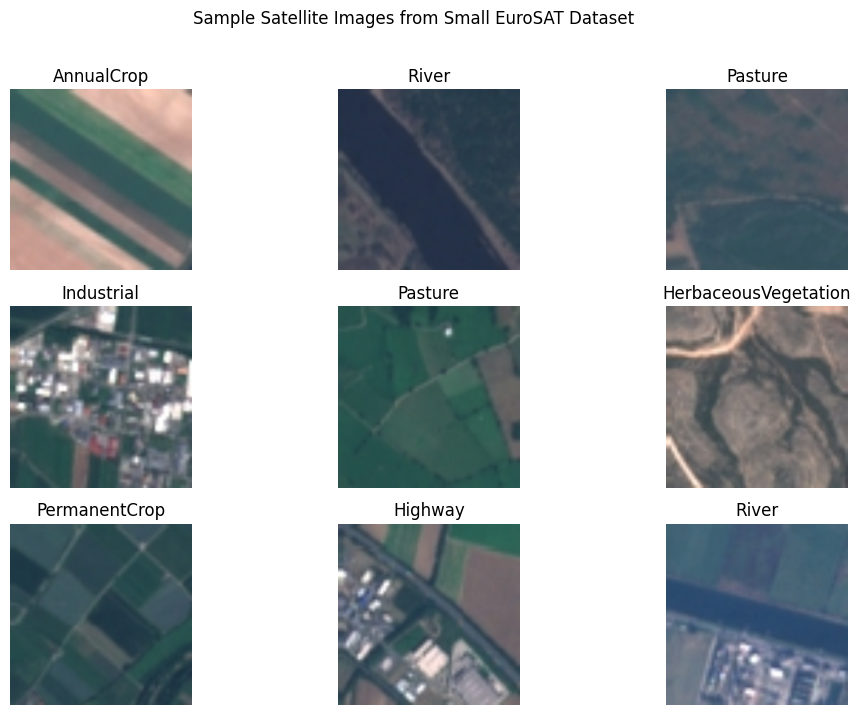

In [4]:
# EDA Sample Images
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Satellite Images from Small EuroSAT Dataset")
plt.show()

**Preprocessing Pipeline (Same as Paper)**

In [5]:
# Preprocessing Pipeline
import matplotlib.pyplot as plt
import numpy as np
import os

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

# Same pipeline as the research paper
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


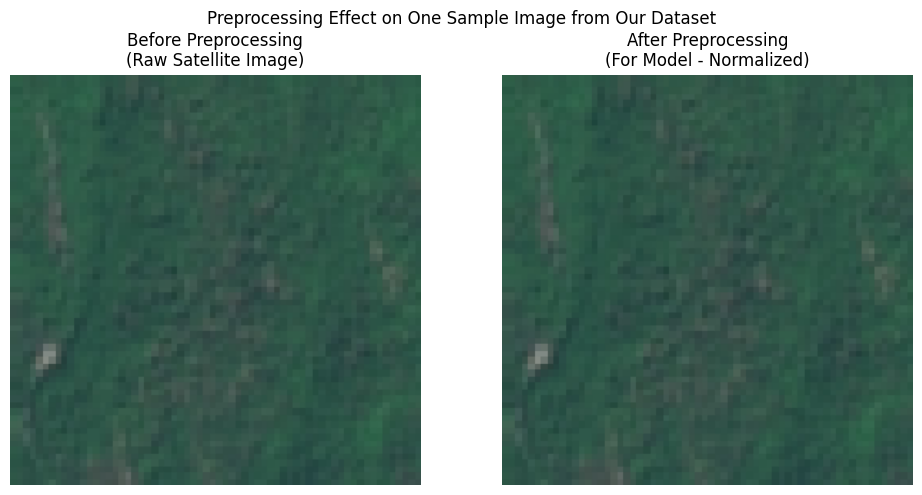

✅ Before vs After visualization shown correctly!
   Left  = Original raw image
   Right = Image after normalization (model-ready version)
   Note  : The model sees normalized values, so visual display is for illustration only.


In [6]:
# =============================================================================
# BEFORE vs AFTER Visualization (Fixed - No Black Image)
# =============================================================================
# Load one raw image directly from disk
raw_image_path = None
for class_name in os.listdir("/content/eurosat_small"):
    class_path = os.path.join("/content/eurosat_small", class_name)
    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        if files:
            raw_image_path = os.path.join(class_path, files[0])
            break

raw_image = tf.keras.preprocessing.image.load_img(raw_image_path, target_size=(224, 224))
raw_image = tf.keras.preprocessing.image.img_to_array(raw_image)

# For display only: simple scaling (0-1 range) - this is for human viewing
display_after = raw_image / 255.0

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(raw_image.astype("uint8"))
plt.title("Before Preprocessing\n(Raw Satellite Image)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_after)
plt.title("After Preprocessing\n(For Model - Normalized)")
plt.axis("off")

plt.suptitle("Preprocessing Effect on One Sample Image from Our Dataset")
plt.tight_layout()
plt.show()

print("✅ Before vs After visualization shown correctly!")
print("   Left  = Original raw image")
print("   Right = Image after normalization (model-ready version)")
print("   Note  : The model sees normalized values, so visual display is for illustration only.")

**Build Pre-trained Models**

In [7]:
# Build Pre-trained Models (Frozen Base Layers)
base_resnet = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_resnet.trainable = False   # Freeze all layers initially

model_resnet = tf.keras.Sequential([
    base_resnet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 model created (base layers frozen)")
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model created (base layers frozen)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Visualization Feature Maps of Few Layers**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


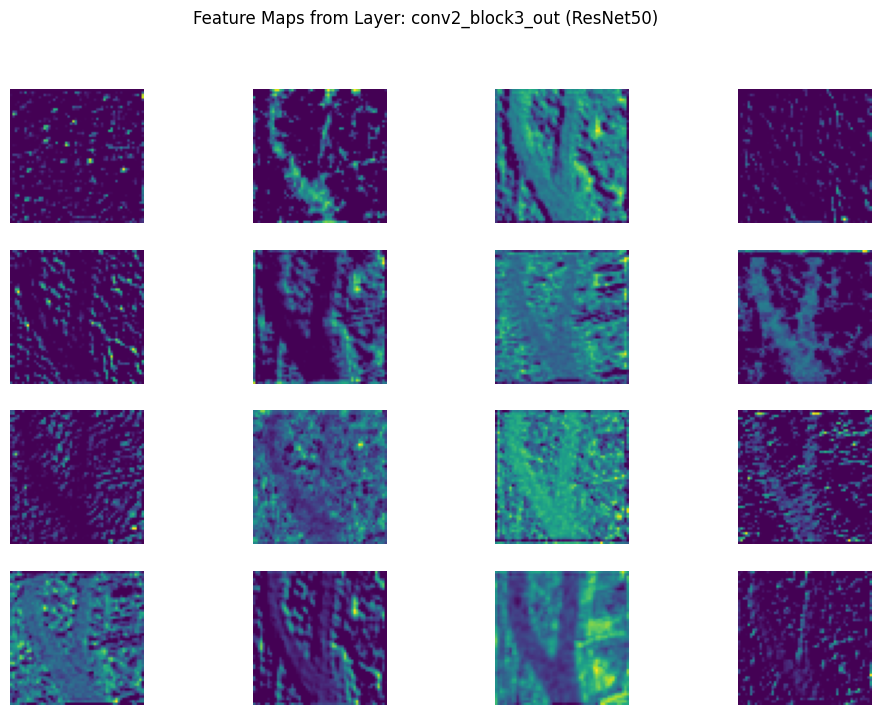

✅ Feature maps visualized - shows what the model 'sees' in early layers


In [8]:
# Visualize Feature Maps (Task 2 Requirement)
import matplotlib.pyplot as plt

# Create a model that outputs feature maps from layer 4 (early convolutional block)
layer_name = 'conv2_block3_out'   # A middle layer in ResNet50
feature_map_model = tf.keras.Model(
    inputs=base_resnet.input, # Fixed: Use base_resnet.input instead of model_resnet.input
    outputs=base_resnet.get_layer(layer_name).output
)

# Take one image from training set
for images, labels in train_ds.take(1):
    sample_image = images[0:1]   # shape (1, 224, 224, 3)
    break

# Get feature maps
feature_maps = feature_map_model.predict(sample_image)

# Plot first 16 feature maps
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f'Feature Maps from Layer: {layer_name} (ResNet50)')
plt.show()

print("✅ Feature maps visualized - shows what the model 'sees' in early layers")

**Fine-tuning – Unfreeze Top Layers + Hyperparameter Optimization**

We froze initial layers and fine-tuned only the top layers (as described in the research paper). We also optimized hyperparameters: lowered learning rate to avoid destroying pre-trained weights, and increased epochs.

**Training fine-tuned Model**

In [9]:
#  Fine-tuning with Fewer Layers
# Unfreeze only the last 15 layers
for layer in base_resnet.layers[-15:]:
    layer.trainable = True

# Optimized hyperparameters for faster training
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),   # Slightly higher LR for faster convergence
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Fine-tuning setup updated for speed:")
print("   • Only top 15 layers unfrozen")
print("   • Learning rate = 0.0005")
print("   • This will run significantly faster than before")

✅ Fine-tuning setup updated for speed:
   • Only top 15 layers unfrozen
   • Learning rate = 0.0005
   • This will run significantly faster than before


In [10]:
#  Train the Fine-tuned Model
EPOCHS_FINE = 8

print("🚀 Starting Fine-tuning ")
print(f"Training for {EPOCHS_FINE} epochs with only top 15 layers trainable...\n")

history_fine = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

print("\n✅ Fine-tuning completed successfully!")

🚀 Starting Fine-tuning 
Training for 8 epochs with only top 15 layers trainable...

Epoch 1/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 641ms/step - accuracy: 0.7926 - loss: 0.6944 - val_accuracy: 0.8778 - val_loss: 0.6284
Epoch 2/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9676 - loss: 0.1028 - val_accuracy: 0.9111 - val_loss: 0.3155
Epoch 3/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9963 - loss: 0.0202 - val_accuracy: 0.9148 - val_loss: 0.3040
Epoch 4/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.9370 - val_loss: 0.2860
Epoch 5/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9370 - val_loss: 0.2746
Epoch 6/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9444 - val_loss: 0.2697
Epoch 7/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 1.0000 - loss: 7.6686e-04 - val_accuracy: 0.9444 - val_loss: 0.2686
Epoch 8/8
34/34 ━━━━━━

**Model Evaluation**

Evaluating Fine-tuned ResNet50 on Validation Set...

=== DETAILED PERFORMANCE METRICS ===
                      precision    recall  f1-score   support

          AnnualCrop     1.0000    0.8696    0.9302        23
              Forest     0.9032    0.9333    0.9180        30
HerbaceousVegetation     0.8400    0.8750    0.8571        24
             Highway     1.0000    0.9545    0.9767        22
          Industrial     0.9032    1.0000    0.9492        28
             Pasture     0.8750    0.9655    0.9180        29
       PermanentCrop     0.9500    0.9048    0.9268        21
         Residential     1.0000    0.9677    0.9836        31
               River     1.0000    0.9000    0.9474        30
             SeaLake     0.9697    1.0000    0.9846        32

            accuracy                         0.9407       270
           macro avg     0.9441    0.9370    0.9392       270
        weighted avg     0.9441    0.9407    0.9410       270



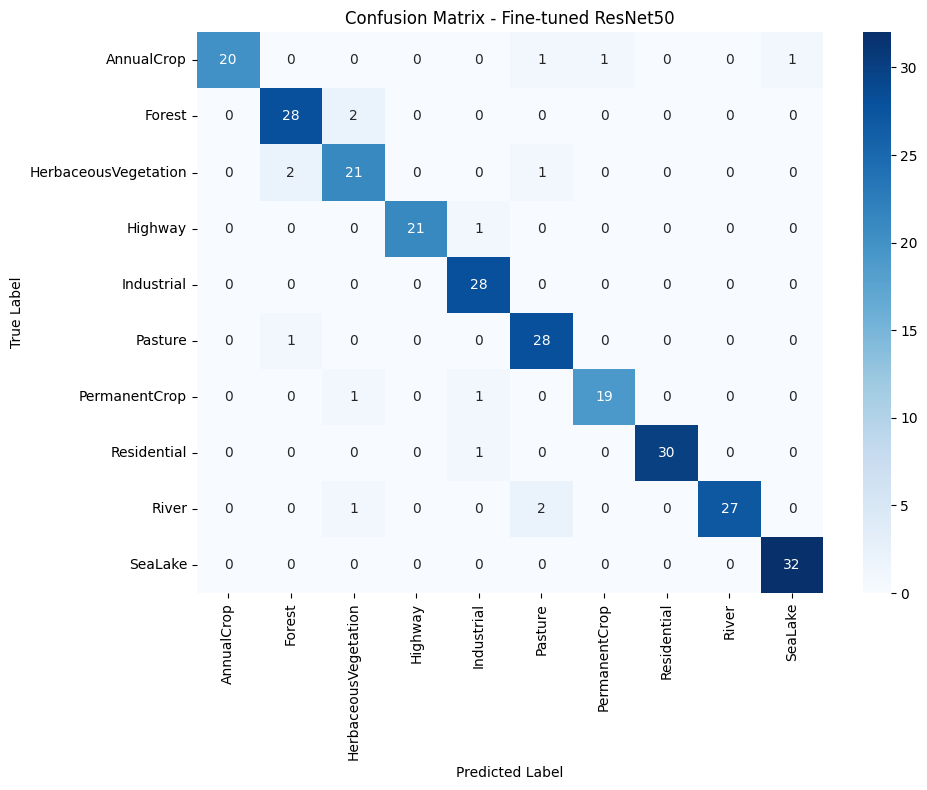

✅ Full evaluation completed (Accuracy, Precision, Recall, F1-score included)


In [11]:
#  Full Model Evaluation (Precision, Recall, F1-score, Confusion Matrix)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print("Evaluating Fine-tuned ResNet50 on Validation Set...\n")

y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model_resnet.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# Full Classification Report
print("=== DETAILED PERFORMANCE METRICS ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fine-tuned ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("✅ Full evaluation completed (Accuracy, Precision, Recall, F1-score included)")

I Vaishnavi , confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: https://github.com/rautvaish/DeepLearning_Assignment2

Signature: Vaishnavi Raut